# Assignment 2 Debug Notebook

- 1단계: 환경과 데이터 로딩 확인
- 2단계: CIFAR-10용 ResNet50 모델 로딩
- 3단계: prediction disagreement 측정
- 4단계: neuron coverage 구현
- 5단계: DeepXplore식 입력 생성 실험


In [31]:
from pathlib import Path
import random

import matplotlib.pyplot as plt
import numpy as np
import torch
from torchvision import datasets, transforms

SEED = 2026
random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)

Path('../results' if Path.cwd().name == 'debug' else 'results').mkdir(exist_ok=True)

print(f'cwd: {Path.cwd().resolve()}')
print(f"device: {'cuda' if torch.cuda.is_available() else 'cpu'}")
print(f'torch: {torch.__version__}')
print(f'cuda available: {torch.cuda.is_available()}')


cwd: /gpfs/home1/ahy0502/trustworthy-ai-assignment2
device: cuda
torch: 2.11.0+cu130
cuda available: True


## Step 1. Load CIFAR-10

데이터셋 다운로드와 기본 전처리가 정상 동작하는지 확인


test samples: 10000
sample shape: (3, 32, 32)
sample label: 3 (cat)
value range: [0.0510, 1.0000]


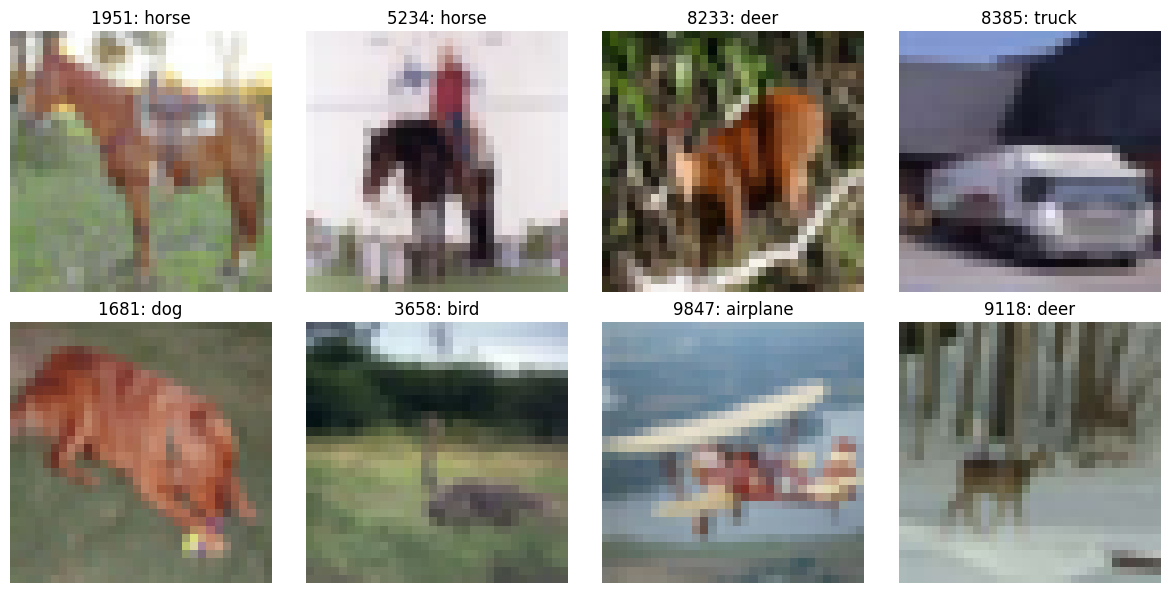

In [32]:
class_names = [
    'airplane', 'automobile', 'bird', 'cat', 'deer',
    'dog', 'frog', 'horse', 'ship', 'truck',
]

# img to tensor
# (H, W, C) in [0, 255] -> (C, H, W) in [0.0, 1.0]
debug_transform = transforms.ToTensor()

test_dataset = datasets.CIFAR10(
    root='../data' if Path.cwd().name == 'debug' else 'data',
    train=False,
    download=True,
    transform=debug_transform,
)

print(f'test samples: {len(test_dataset)}')
sample_img, sample_label = test_dataset[0]
print(f'sample shape: {tuple(sample_img.shape)}')
print(f'sample label: {sample_label} ({class_names[sample_label]})')
print(f'value range: [{sample_img.min().item():.4f}, {sample_img.max().item():.4f}]')
indices = random.sample(range(len(test_dataset)), 8)
fig, axes = plt.subplots(2, 4, figsize=(12, 6))

for ax, idx in zip(axes.flat, indices):
    image, label = test_dataset[idx]
    ax.imshow(image.permute(1, 2, 0).numpy())
    ax.set_title(f'{idx}: {class_names[label]}')
    ax.axis('off')

plt.tight_layout()
plt.show()


## Step 2. Build CIFAR-10 ResNet50 Models

`CIFAR-10` 입력 크기에 맞도록 기존 `ResNet50` 변경 및 확인


In [33]:
from torch import nn
from torch.utils.data import DataLoader
from torchvision.models import resnet50
from tqdm.auto import tqdm

cifar10_mean = (0.4914, 0.4822, 0.4465)
cifar10_std = (0.2470, 0.2435, 0.2616)

# preprocess
model_input_transform = transforms.Compose([
    transforms.ToTensor(),
    transforms.Normalize(mean=cifar10_mean, std=cifar10_std),
])

# test dataset for model input
model_test_dataset = datasets.CIFAR10(
    root='../data' if Path.cwd().name == 'debug' else 'data',
    train=False,
    download=True,
    transform=model_input_transform,
)

model_test_loader = DataLoader(
    model_test_dataset,
    batch_size=16,
    shuffle=False,
    num_workers=0,
    pin_memory=torch.cuda.is_available(),
)

# resnet50 for cifar10
def build_cifar10_resnet50(random_seed):
    torch.manual_seed(random_seed)
    cifar10_resnet50_model = resnet50(weights=None)
    # modification for cifar10
    cifar10_resnet50_model.conv1 = nn.Conv2d(
        in_channels=3,
        out_channels=64,
        kernel_size=3,
        stride=1,
        padding=1,
        bias=False,
    )
    cifar10_resnet50_model.maxpool = nn.Identity()
    cifar10_resnet50_model.fc = nn.Linear(
        in_features=cifar10_resnet50_model.fc.in_features,
        out_features=len(class_names),
    )
    if torch.cuda.is_available():
        cifar10_resnet50_model = cifar10_resnet50_model.cuda()
    return cifar10_resnet50_model

# diff seeds for diff models
model_random_seed_list = [2026, 2027]
model_name_list = ['resnet50_wo_aug', 'resnet50_w_aug']
resnet50_model_list = [build_cifar10_resnet50(seed) for seed in model_random_seed_list]

input_batch, label_batch = next(iter(model_test_loader))
if torch.cuda.is_available():
    input_batch = input_batch.cuda()

print(f'input batch shape: {tuple(input_batch.shape)}')
print(f'label batch shape: {tuple(label_batch.shape)}')

for model_name, resnet50_model in zip(model_name_list, resnet50_model_list):
    resnet50_model.eval()
    with torch.no_grad():
        output_logits = resnet50_model(input_batch)
    predicted_class_index_list = output_logits.argmax(dim=1)[:5].cpu().tolist()
    predicted_class_name_list = [class_names[index] for index in predicted_class_index_list]
    trainable_parameter_count = sum(parameter.numel() for parameter in resnet50_model.parameters())
    print(f'\n{model_name}')
    print(f'logits shape: {tuple(output_logits.shape)}')
    print(f'trainable parameter count: {trainable_parameter_count:,}')
    print(f'first 5 predicted classes: {predicted_class_name_list}')


input batch shape: (16, 3, 32, 32)
label batch shape: (16,)

resnet50_wo_aug
logits shape: (16, 10)
trainable parameter count: 23,520,842
first 5 predicted classes: ['deer', 'deer', 'deer', 'deer', 'deer']

resnet50_w_aug
logits shape: (16, 10)
trainable parameter count: 23,520,842
first 5 predicted classes: ['airplane', 'airplane', 'airplane', 'airplane', 'airplane']


## Step 3. Split Training Settings

`test` preprocessing은 동일하게 유지하고, `train`에서는 한 모델은 augmentation 없이, 다른 모델은 augmentation을 적용


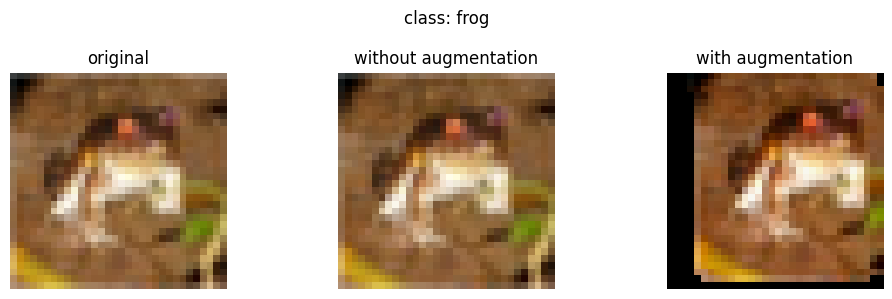

train samples without augmentation: 50000
train samples with augmentation: 50000
train batch shape without augmentation: (128, 3, 32, 32)
train batch shape with augmentation: (128, 3, 32, 32)


In [34]:
def unnormalize_image(normalized_image_tensor):
    mean_tensor = torch.tensor(cifar10_mean).view(3, 1, 1)
    std_tensor = torch.tensor(cifar10_std).view(3, 1, 1)
    restored_image_tensor = normalized_image_tensor.cpu() * std_tensor + mean_tensor
    return restored_image_tensor.clamp(0.0, 1.0)

# wo/ aug
train_transform_wo_aug = transforms.Compose([
    transforms.ToTensor(),
    transforms.Normalize(mean=cifar10_mean, std=cifar10_std),
])

# w/ aug
# random crop, color jitter, random rotation
train_transform_w_aug = transforms.Compose([
    transforms.RandomCrop(size=32, padding=4),
    transforms.ColorJitter(brightness=0.2, contrast=0.2, saturation=0.2, hue=0.02),
    transforms.RandomRotation(degrees=12),
    transforms.ToTensor(),
    transforms.Normalize(mean=cifar10_mean, std=cifar10_std),
])

train_dataset_wo_aug = datasets.CIFAR10(
    root='../data' if Path.cwd().name == 'debug' else 'data',
    train=True,
    download=True,
    transform=train_transform_wo_aug,
)

train_dataset_w_aug = datasets.CIFAR10(
    root='../data' if Path.cwd().name == 'debug' else 'data',
    train=True,
    download=True,
    transform=train_transform_w_aug,
)

train_loader_wo_aug = DataLoader(
    train_dataset_wo_aug,
    batch_size=128,
    shuffle=True,
    num_workers=0,
    pin_memory=torch.cuda.is_available(),
)

train_loader_w_aug = DataLoader(
    train_dataset_w_aug,
    batch_size=128,
    shuffle=True,
    num_workers=0,
    pin_memory=torch.cuda.is_available(),
)

raw_train_dataset = datasets.CIFAR10(
    root='../data' if Path.cwd().name == 'debug' else 'data',
    train=True,
    download=True,
    transform=transforms.ToTensor(),
)

sample_index = 0
original_image_tensor, original_label_index = raw_train_dataset[sample_index]
image_wo_aug, _ = train_dataset_wo_aug[sample_index]
image_w_aug, _ = train_dataset_w_aug[sample_index]

figure, axis_list = plt.subplots(1, 3, figsize=(10, 3))
axis_list[0].imshow(original_image_tensor.permute(1, 2, 0).numpy())
axis_list[0].set_title('original')
axis_list[1].imshow(unnormalize_image(image_wo_aug).permute(1, 2, 0).numpy())
axis_list[1].set_title('without augmentation')
axis_list[2].imshow(unnormalize_image(image_w_aug).permute(1, 2, 0).numpy())
axis_list[2].set_title('with augmentation')

for axis in axis_list:
    axis.axis('off')

plt.suptitle(f'class: {class_names[original_label_index]}')
plt.tight_layout()
plt.show()

print(f'train samples without augmentation: {len(train_dataset_wo_aug)}')
print(f'train samples with augmentation: {len(train_dataset_w_aug)}')

train_input_batch_wo_aug, train_label_batch_wo_aug = next(iter(train_loader_wo_aug))
train_input_batch_w_aug, train_label_batch_w_aug = next(iter(train_loader_w_aug))

print(f'train batch shape without augmentation: {tuple(train_input_batch_wo_aug.shape)}')
print(f'train batch shape with augmentation: {tuple(train_input_batch_w_aug.shape)}')

## Step 4. Build Training Loop

학습 구성


In [35]:
Path('../ckpts' if Path.cwd().name == 'debug' else 'ckpts').mkdir(exist_ok=True)

# hyperparameters
val_ratio = 0.1
training_epoch_count = 20
training_learning_rate = 0.1
training_momentum = 0.9
training_weight_decay = 5e-4

# True: start training
# False: sanity check
run_training_now = False

split_random_generator = torch.Generator().manual_seed(SEED)
all_train_index_tensor = torch.randperm(len(train_dataset_wo_aug), generator=split_random_generator)
val_sample_count = int(len(all_train_index_tensor) * val_ratio)
val_index_list = all_train_index_tensor[:val_sample_count].tolist()
train_index_list = all_train_index_tensor[val_sample_count:].tolist()

train_subset_wo_aug = torch.utils.data.Subset(train_dataset_wo_aug, train_index_list)
train_subset_w_aug = torch.utils.data.Subset(train_dataset_w_aug, train_index_list)

val_dataset = datasets.CIFAR10(
    root='../data' if Path.cwd().name == 'debug' else 'data',
    train=True,
    download=True,
    transform=model_input_transform,
)
val_subset = torch.utils.data.Subset(val_dataset, val_index_list)

train_loader_wo_aug = DataLoader(
    train_subset_wo_aug,
    batch_size=128,
    shuffle=True,
    num_workers=0,
    pin_memory=torch.cuda.is_available(),
)

train_loader_w_aug = DataLoader(
    train_subset_w_aug,
    batch_size=128,
    shuffle=True,
    num_workers=0,
    pin_memory=torch.cuda.is_available(),
)

val_loader = DataLoader(
    val_subset,
    batch_size=256,
    shuffle=False,
    num_workers=0,
    pin_memory=torch.cuda.is_available(),
)

def cal_acc(output_logits, label_index_tensor):
    predicted_label_index_tensor = output_logits.argmax(dim=1)
    correct_prediction_count = (predicted_label_index_tensor == label_index_tensor).sum().item()
    sample_count = label_index_tensor.size(0)
    return correct_prediction_count / sample_count

def train_one_epoch(model_name, resnet50_model, train_loader, loss_function, optimizer):
    resnet50_model.train()
    loss_sum = 0.0
    accuracy_sum = 0.0
    batch_count = 0

    train_progress_bar = tqdm(
        train_loader,
        desc=f'{model_name} train',
        leave=False,
        dynamic_ncols=True,
    )

    for input_batch, label_batch in train_progress_bar:
        if torch.cuda.is_available():
            input_batch = input_batch.cuda(non_blocking=True)
            label_batch = label_batch.cuda(non_blocking=True)

        optimizer.zero_grad()
        output_logits = resnet50_model(input_batch)
        loss_value = loss_function(output_logits, label_batch)
        loss_value.backward()
        optimizer.step()

        loss_sum += loss_value.item()
        accuracy_sum += cal_acc(output_logits, label_batch)
        batch_count += 1
        train_progress_bar.set_postfix(
            loss=f'{loss_sum / batch_count:.4f}',
            acc=f'{accuracy_sum / batch_count:.4f}',
        )

    return loss_sum / batch_count, accuracy_sum / batch_count

def eval_model(model_name, resnet50_model, eval_loader, loss_function):
    resnet50_model.eval()
    loss_sum = 0.0
    accuracy_sum = 0.0
    batch_count = 0

    eval_progress_bar = tqdm(
        eval_loader,
        desc=f'{model_name} eval',
        leave=False,
        dynamic_ncols=True,
    )

    with torch.no_grad():
        for input_batch, label_batch in eval_progress_bar:
            if torch.cuda.is_available():
                input_batch = input_batch.cuda(non_blocking=True)
                label_batch = label_batch.cuda(non_blocking=True)

            output_logits = resnet50_model(input_batch)
            loss_value = loss_function(output_logits, label_batch)

            loss_sum += loss_value.item()
            accuracy_sum += cal_acc(output_logits, label_batch)
            batch_count += 1
            eval_progress_bar.set_postfix(
                loss=f'{loss_sum / batch_count:.4f}',
                acc=f'{accuracy_sum / batch_count:.4f}',
            )

    return loss_sum / batch_count, accuracy_sum / batch_count

def train_model(model_name, resnet50_model, train_loader, val_loader):
    loss_function = nn.CrossEntropyLoss()
    optimizer = torch.optim.SGD(
        resnet50_model.parameters(),
        lr=training_learning_rate,
        momentum=training_momentum,
        weight_decay=training_weight_decay,
    )
    learning_rate_scheduler = torch.optim.lr_scheduler.CosineAnnealingLR(
        optimizer,
        T_max=training_epoch_count,
    )
    checkpoint_path = Path('../ckpts' if Path.cwd().name == 'debug' else 'ckpts') / f'{model_name}.pt'
    training_history_list = []
    best_val_accuracy = -1.0

    epoch_progress_bar = tqdm(
        range(training_epoch_count),
        desc=f'{model_name} epochs',
        leave=True,
        dynamic_ncols=True,
    )

    for epoch_index in epoch_progress_bar:
        train_loss, train_accuracy = train_one_epoch(
            model_name,
            resnet50_model,
            train_loader,
            loss_function,
            optimizer,
        )
        val_loss, val_accuracy = eval_model(
            model_name,
            resnet50_model,
            val_loader,
            loss_function,
        )
        learning_rate_scheduler.step()

        epoch_result = {
            'epoch': epoch_index + 1,
            'train_loss': train_loss,
            'train_accuracy': train_accuracy,
            'val_loss': val_loss,
            'val_accuracy': val_accuracy,
        }
        training_history_list.append(epoch_result)
        epoch_progress_bar.set_postfix(
            train_loss=f'{train_loss:.4f}',
            train_acc=f'{train_accuracy:.4f}',
            val_loss=f'{val_loss:.4f}',
            val_acc=f'{val_accuracy:.4f}',
        )

        if val_accuracy > best_val_accuracy:
            best_val_accuracy = val_accuracy
            torch.save(
                {
                    'model_name': model_name,
                    'model_state_dict': resnet50_model.state_dict(),
                    'epoch': epoch_index + 1,
                    'val_accuracy': val_accuracy,
                },
                checkpoint_path,
            )

        print(
            f"{model_name} | epoch {epoch_index + 1:02d}/{training_epoch_count} | "
            f"train loss {train_loss:.4f} | train acc {train_accuracy:.4f} | "
            f"val loss {val_loss:.4f} | val acc {val_accuracy:.4f}"
        )

    return training_history_list, checkpoint_path

training_setup_list = [
    {
        'model_name': 'resnet50_wo_aug',
        'resnet50_model': resnet50_model_list[0],
        'train_loader': train_loader_wo_aug,
    },
    {
        'model_name': 'resnet50_w_aug',
        'resnet50_model': resnet50_model_list[1],
        'train_loader': train_loader_w_aug,
    },
]

print(f'train split size: {len(train_index_list)}')
print(f'val split size: {len(val_index_list)}')
print(f"ckpts dir: {'../ckpts' if Path.cwd().name == 'debug' else 'ckpts'}")

if run_training_now:
    training_result_dict = {}
    for training_setup in training_setup_list:
        training_history_list, checkpoint_path = train_model(
            model_name=training_setup['model_name'],
            resnet50_model=training_setup['resnet50_model'],
            train_loader=training_setup['train_loader'],
            val_loader=val_loader,
        )
        training_result_dict[training_setup['model_name']] = {
            'history': training_history_list,
            'checkpoint_path': checkpoint_path,
        }
else:
    print('training loop ready')
    print('set run_training_now = True to start training')


train split size: 45000
val split size: 5000
ckpts dir: ckpts
training loop ready
set run_training_now = True to start training


## Step 5. Load Ckpts And Compare Clean Test Results

저장된 checkpoint를 다시 불러와 `test accuracy`와 `clean disagreement`를 확인


resnet50_wo_aug eval:   0%|                                                                                   …

resnet50_wo_aug | saved epoch 20 | val acc 0.8387 | test loss 0.7445 | test acc 0.8276


resnet50_w_aug eval:   0%|                                                                                    …

resnet50_w_aug | saved epoch 20 | val acc 0.8279 | test loss 0.5206 | test acc 0.8227


resnet50_wo_aug predict:   0%|                                                                                …

resnet50_w_aug predict:   0%|                                                                                 …

clean disagreement count: 1883
clean disagreement rate: 0.1883


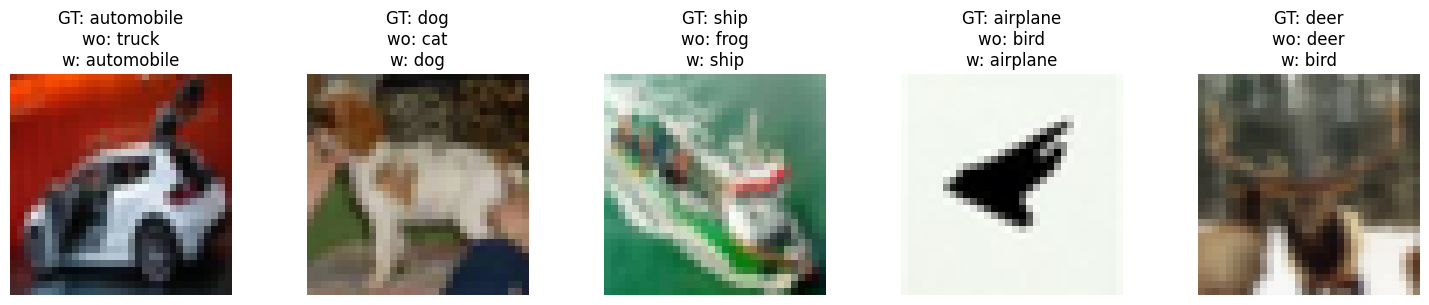

In [36]:
def load_trained_resnet50(model_name, random_seed):
    trained_resnet50_model = build_cifar10_resnet50(random_seed)
    checkpoint = torch.load(
        Path('../ckpts' if Path.cwd().name == 'debug' else 'ckpts') / f'{model_name}.pt',
        map_location='cuda' if torch.cuda.is_available() else 'cpu',
    )
    trained_resnet50_model.load_state_dict(checkpoint['model_state_dict'])
    trained_resnet50_model.eval()
    return trained_resnet50_model, checkpoint

def collect_prediction_tensor(model_name, resnet50_model, data_loader):
    predicted_label_index_tensor_list = []
    true_label_index_tensor_list = []

    prediction_progress_bar = tqdm(
        data_loader,
        desc=f'{model_name} predict',
        leave=False,
        dynamic_ncols=True,
    )

    with torch.no_grad():
        for input_batch, label_batch in prediction_progress_bar:
            if torch.cuda.is_available():
                input_batch = input_batch.cuda(non_blocking=True)

            output_logits = resnet50_model(input_batch)
            predicted_label_index_tensor_list.append(output_logits.argmax(dim=1).cpu())
            true_label_index_tensor_list.append(label_batch.cpu())

    return torch.cat(predicted_label_index_tensor_list), torch.cat(true_label_index_tensor_list)

test_loss_function = nn.CrossEntropyLoss()
trained_model_list = []

for model_name, random_seed in zip(model_name_list, model_random_seed_list):
    trained_resnet50_model, checkpoint = load_trained_resnet50(model_name, random_seed)
    trained_model_list.append(trained_resnet50_model)
    test_loss, test_accuracy = eval_model(
        model_name,
        trained_resnet50_model,
        model_test_loader,
        test_loss_function,
    )
    print(
        f"{model_name} | saved epoch {checkpoint['epoch']} | "
        f"val acc {checkpoint['validation_accuracy']:.4f} | "
        f"test loss {test_loss:.4f} | test acc {test_accuracy:.4f}"
    )

predicted_label_index_tensor_for_wo_aug, true_label_index_tensor = collect_prediction_tensor(
    'resnet50_wo_aug',
    trained_model_list[0],
    model_test_loader,
)

predicted_label_index_tensor_for_w_aug, _ = collect_prediction_tensor(
    'resnet50_w_aug',
    trained_model_list[1],
    model_test_loader,
)

disagreement_index_list = torch.nonzero(
    predicted_label_index_tensor_for_wo_aug != predicted_label_index_tensor_for_w_aug,
    as_tuple=False,
).view(-1).tolist()

print(f'clean disagreement count: {len(disagreement_index_list)}')
print(f'clean disagreement rate: {len(disagreement_index_list) / len(model_test_dataset):.4f}')

raw_test_dataset = datasets.CIFAR10(
    root='../data' if Path.cwd().name == 'debug' else 'data',
    train=False,
    download=True,
    transform=transforms.ToTensor(),
)

disagreement_example_count = min(5, len(disagreement_index_list))

if disagreement_example_count > 0:
    figure, axis_list = plt.subplots(1, disagreement_example_count, figsize=(3 * disagreement_example_count, 3))
    if disagreement_example_count == 1:
        axis_list = [axis_list]

    for axis, disagreement_index in zip(axis_list, disagreement_index_list[:disagreement_example_count]):
        image_tensor, true_label_index = raw_test_dataset[disagreement_index]
        predicted_label_index_for_wo_aug = predicted_label_index_tensor_for_wo_aug[disagreement_index].item()
        predicted_label_index_for_w_aug = predicted_label_index_tensor_for_w_aug[disagreement_index].item()

        axis.imshow(image_tensor.permute(1, 2, 0).numpy())
        axis.set_title(
            f'GT: {class_names[true_label_index]}\n'
            f'wo: {class_names[predicted_label_index_for_wo_aug]}\n'
            f'w: {class_names[predicted_label_index_for_w_aug]}'
        )
        axis.axis('off')

    plt.tight_layout()
    plt.show()
else:
    print('clean disagreement example not found')


## Step 6. Prepare DeepXplore-Style Utils

DeepXplore `utils.py`에 들어가는 helper들을 PyTorch/CIFAR-10 실험에 맞게 준비


In [ ]:
from collections import defaultdict
import random

# covered = activated neuron
threshold = 0.2                 # over 0.2 means activated neuron
coverage_batch_size = 128       
coverage_batch_limit = None     # None: total test set

coverage_test_loader = DataLoader(
    model_test_dataset,
    batch_size=coverage_batch_size,
    shuffle=False,
    num_workers=0,
    pin_memory=torch.cuda.is_available(),
)

def deprocess_image(input_tensor):
    return input_tensor.detach().cpu().clamp(0.0, 1.0).permute(1, 2, 0).numpy()

def normalize(input_tensor):
    return input_tensor / (torch.sqrt(torch.mean(torch.square(input_tensor))) + 1e-5)

# scale output of layer to [rmin, rmax] = [0, 1]
def scale(intermediate_layer_output, rmax=1, rmin=0):
    minimum_value = intermediate_layer_output.min()
    maximum_value = intermediate_layer_output.max()
    if (maximum_value - minimum_value).abs().item() < 1e-8:
        return torch.zeros_like(intermediate_layer_output) + rmin
    scaled_output = (intermediate_layer_output - minimum_value) / (maximum_value - minimum_value)
    return scaled_output * (rmax - rmin) + rmin

coverage_layer_type_tuple = (
    nn.Conv2d,
    nn.Linear,
    nn.BatchNorm2d,
    nn.ReLU,
    nn.AdaptiveAvgPool2d,
    nn.Identity,
)
coverage_layer_spec_cache = {}

def format_coverage_layer_name(layer_name, call_index):
    if call_index == 1:
        return layer_name
    return f'{layer_name}#{call_index}'

def parse_coverage_layer_name(coverage_layer_name):
    if '#' not in coverage_layer_name:
        return coverage_layer_name, 1
    layer_name, call_index = coverage_layer_name.rsplit('#', 1)
    return layer_name, int(call_index)

def build_coverage_layer_spec(model):
    layer_spec_list = []
    hook_handle_list = []
    layer_call_count_dict = defaultdict(int)

    for layer_name, layer_module in model.named_modules():
        if isinstance(layer_module, coverage_layer_type_tuple):
            def save_output(module, input_value, output_value, layer_name=layer_name):
                layer_call_count_dict[layer_name] += 1
                call_index = layer_call_count_dict[layer_name]
                coverage_layer_name = format_coverage_layer_name(layer_name, call_index)
                neuron_count = output_value.shape[1] if output_value.dim() >= 2 else output_value.shape[0]
                layer_spec_list.append((coverage_layer_name, neuron_count))

            hook_handle_list.append(layer_module.register_forward_hook(save_output))

    model.eval()
    with torch.no_grad():
        dummy_input = torch.zeros(1, 3, 32, 32, device=next(model.parameters()).device)
        _ = model(dummy_input)

    for hook_handle in hook_handle_list:
        hook_handle.remove()

    return layer_spec_list

def get_coverage_layer_spec(model):
    model_key = id(model)
    if model_key not in coverage_layer_spec_cache:
        coverage_layer_spec_cache[model_key] = build_coverage_layer_spec(model)
    return coverage_layer_spec_cache[model_key]

# init coverage map
# key: (layer_name, neuron_index), value: true (covered), false (not covered)
def init_dict(model, model_layer_dict):
    for coverage_layer_name, neuron_count in get_coverage_layer_spec(model):
        for index in range(neuron_count):
            model_layer_dict[(coverage_layer_name, index)] = False

# create coverage tables for two models
def init_coverage_tables(model1, model2):
    model_layer_dict1 = defaultdict(bool)
    model_layer_dict2 = defaultdict(bool)
    init_dict(model1, model_layer_dict1)
    init_dict(model2, model_layer_dict2)
    return model_layer_dict1, model_layer_dict2

# pick random neuron that is not covered, used to select uncovered neuron as target neuron and activate to change pred
def neuron_to_cover(model_layer_dict):
    not_covered = [(layer_name, index) for (layer_name, index), covered in model_layer_dict.items() if not covered]
    if len(not_covered) > 0:
        return random.choice(not_covered)
    return random.choice(list(model_layer_dict.keys()))

# calculate covered neuron count, total neuron count, and coverage percentage
def neuron_covered(model_layer_dict):
    covered_neurons = len([covered for covered in model_layer_dict.values() if covered])
    total_neurons = len(model_layer_dict)
    return covered_neurons, total_neurons, covered_neurons / float(total_neurons)

# check input, layer, neuron index and update coverage table
def update_coverage(input_data, model, model_layer_dict, threshold=0):
    layer_output_dict = {}
    hook_handle_list = []

    layer_call_count_dict = defaultdict(int)

    for layer_name, layer_module in model.named_modules():
        if isinstance(layer_module, coverage_layer_type_tuple):
            def save_output(module, input_value, output_value, layer_name=layer_name):
                layer_call_count_dict[layer_name] += 1
                call_index = layer_call_count_dict[layer_name]
                coverage_layer_name = format_coverage_layer_name(layer_name, call_index)
                layer_output_dict[coverage_layer_name] = output_value.detach()
            hook_handle_list.append(layer_module.register_forward_hook(save_output))

    model.eval()
    with torch.no_grad():
        _ = model(input_data)

    for hook_handle in hook_handle_list:
        hook_handle.remove()

    for layer_name, layer_output in layer_output_dict.items():
        # match the original DeepXplore implementation and use only the first sample in the batch
        scaled_output = scale(layer_output[0].float())
        for num_neuron in range(scaled_output.shape[0]):
            if scaled_output[num_neuron].mean().item() > threshold and not model_layer_dict[(layer_name, num_neuron)]:
                model_layer_dict[(layer_name, num_neuron)] = True

# check input, layer, neuron index and output T/F
def fired(model, layer_name, index, input_data, threshold=0):
    layer_output_dict = {}
    actual_layer_name, target_call_index = parse_coverage_layer_name(layer_name)
    layer_call_count_dict = defaultdict(int)

    def save_output(module, input_value, output_value):
        layer_call_count_dict[actual_layer_name] += 1
        if layer_call_count_dict[actual_layer_name] == target_call_index:
            layer_output_dict['layer_output'] = output_value.detach()

    layer_module = dict(model.named_modules())[actual_layer_name]
    hook_handle = layer_module.register_forward_hook(save_output)
    model.eval()
    with torch.no_grad():
        _ = model(input_data)
    hook_handle.remove()

    scaled_output = scale(layer_output_dict['layer_output'][0].float())
    return scaled_output[index].mean().item() > threshold

def diverged(predictions1, predictions2, target_model):
    if predictions1 != predictions2:
        return True
    return False



## Step 7. Measure Neuron Coverage On Clean Test Inputs

DeepXplore 핵심 지표인 `neuron coverage`를 clean test set 기준으로 측정


In [37]:
model_layer_dict1, model_layer_dict2 = init_coverage_tables(
    trained_model_list[0],
    trained_model_list[1],
)

coverage_progress_bar = tqdm(
    coverage_test_loader,
    desc='update coverage',
    leave=False,
    dynamic_ncols=True,
)

for batch_index, (input_batch, _) in enumerate(coverage_progress_bar):
    if coverage_batch_limit is not None and batch_index >= coverage_batch_limit:
        break

    if torch.cuda.is_available():
        input_batch = input_batch.cuda(non_blocking=True)

    update_coverage(input_batch, trained_model_list[0], model_layer_dict1, threshold)
    update_coverage(input_batch, trained_model_list[1], model_layer_dict2, threshold)

covered_neurons1, total_neurons1, neuron_coverage1 = neuron_covered(model_layer_dict1)
covered_neurons2, total_neurons2, neuron_coverage2 = neuron_covered(model_layer_dict2)
average_neuron_coverage = (covered_neurons1 + covered_neurons2) / float(total_neurons1 + total_neurons2)

print(
    f"{model_name_list[0]} | covered neurons {covered_neurons1}/{total_neurons1} | "
    f"neuron coverage {neuron_coverage1:.4f}"
)
print(
    f"{model_name_list[1]} | covered neurons {covered_neurons2}/{total_neurons2} | "
    f"neuron coverage {neuron_coverage2:.4f}"
)
print(f'average neuron coverage: {average_neuron_coverage:.4f}')


update coverage:   0%|                                                                                        …

resnet50_wo_aug | covered neurons 38126/77962 | neuron coverage 0.4890
resnet50_w_aug | covered neurons 38485/77962 | neuron coverage 0.4936
average neuron coverage: 0.4913


## Step 8. Generate Disagreement-Inducing Inputs

이 단계는 clean test input 중 원래는 두 모델이 같은 예측을 하던 seed를 골라 perturbation을 주고,
`prediction disagreement`와 `coverage-oriented activation`을 함께 키우는 방향으로 입력을 생성하는 단계임


gen_diff:   0%|                                                                                               …

target model: resnet50_wo_aug
generated disagreement count: 5


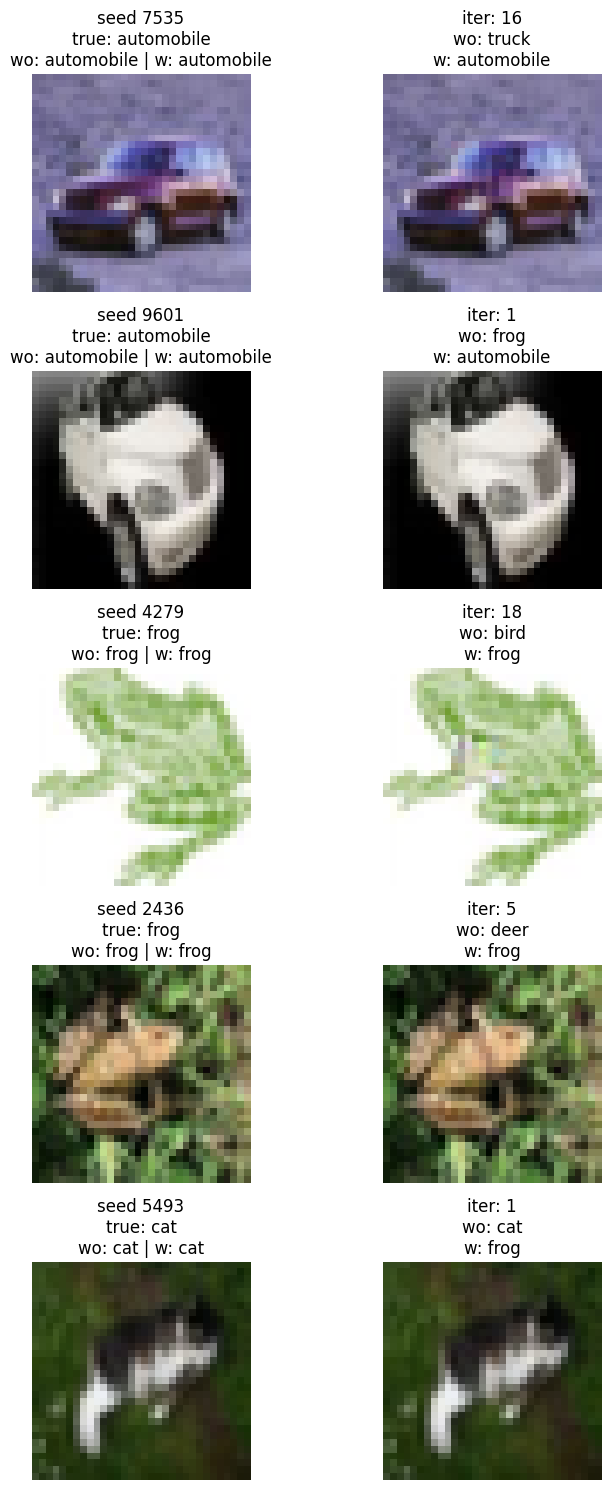

In [43]:
transformation = 'occl'     # occl, light, black
weight_diff = 5.0           # weight for loss to increase diff of two models
weight_nc = 0.5             # weight for loss to increase neuron coverage
step = 1 / 255              # step size for gradient update
seeds = 200
grad_iterations = 20        
target_model = 0
max_perturbation = 100 / 255  # perturbation budget
generated_input_limit = 5   # generate 5 and done

# occl params
start_point = (10, 10)
occlusion_size = (8, 8)

def preprocess_image(image_tensor):
    mean_tensor = image_tensor.new_tensor(cifar10_mean).view(3, 1, 1)
    std_tensor = image_tensor.new_tensor(cifar10_std).view(3, 1, 1)
    return (image_tensor - mean_tensor) / std_tensor

# perturb certain region of image
def constraint_occl(gradients, start_point, rect_shape):
    new_grads = torch.zeros_like(gradients)
    new_grads[:, start_point[0]:start_point[0] + rect_shape[0], start_point[1]:start_point[1] + rect_shape[1]] = (
        gradients[:, start_point[0]:start_point[0] + rect_shape[0], start_point[1]:start_point[1] + rect_shape[1]]
    )
    return new_grads

# perturb light by changing all pixels with same value
def constraint_light(gradients):
    return gradients.mean() * torch.ones_like(gradients)

# perturb certain region of image with black patch
def constraint_black(gradients, rect_shape=(6, 6)):
    start_row = random.randint(0, gradients.shape[1] - rect_shape[0])
    start_col = random.randint(0, gradients.shape[2] - rect_shape[1])
    new_grads = torch.zeros_like(gradients)
    patch = gradients[:, start_row:start_row + rect_shape[0], start_col:start_col + rect_shape[1]]
    if patch.mean().item() < 0:
        new_grads[:, start_row:start_row + rect_shape[0], start_col:start_col + rect_shape[1]] = -torch.ones_like(patch)
    return new_grads

def predict_label(model, image_tensor):
    model.eval()
    with torch.no_grad():
        return model(preprocess_image(image_tensor).unsqueeze(0)).argmax(dim=1).item()

# prepare for two loss
# class output diff loss
# target neuron activation loss
def forward_layer(model, input_data, layer_name):
    layer_output_dict = {}
    actual_layer_name, target_call_index = parse_coverage_layer_name(layer_name)
    layer_call_count_dict = defaultdict(int)

    def save_output(module, input_value, output_value):
        layer_call_count_dict[actual_layer_name] += 1
        if layer_call_count_dict[actual_layer_name] == target_call_index:
            layer_output_dict['layer_output'] = output_value

    layer_module = dict(model.named_modules())[actual_layer_name]
    hook_handle = layer_module.register_forward_hook(save_output)
    output = model(input_data)
    hook_handle.remove()
    return output, layer_output_dict['layer_output']

Path('../results/generated_inputs' if Path.cwd().name == 'debug' else 'results/generated_inputs').mkdir(parents=True, exist_ok=True)

model1 = trained_model_list[0]
model2 = trained_model_list[1]

# use agreement samples
agreement_index_list = torch.nonzero(
    predicted_label_index_tensor_for_wo_aug == predicted_label_index_tensor_for_w_aug,
    as_tuple=False,
).view(-1).tolist()
random.shuffle(agreement_index_list)

generated_result_list = []
generation_progress_bar = tqdm(
    agreement_index_list[:seeds],
    desc='gen_diff',
    leave=False,
    dynamic_ncols=True,
)

print(f'target model: {model_name_list[target_model]}')

for seed_index in generation_progress_bar:
    gen_img, true_label = raw_test_dataset[seed_index]
    if torch.cuda.is_available():
        gen_img = gen_img.cuda()

    # save original img and pred
    orig_img = gen_img.clone()
    label1 = predict_label(model1, gen_img)
    label2 = predict_label(model2, gen_img)

    # choose uncovered neuron as target
    orig_label = label1
    layer_name1, index1 = neuron_to_cover(model_layer_dict1)
    layer_name2, index2 = neuron_to_cover(model_layer_dict2)

    for iters in range(grad_iterations):
        gen_img = gen_img.detach().requires_grad_(True)
        input_data = preprocess_image(gen_img).unsqueeze(0)

        # calculate two losses
        output1, layer_output1 = forward_layer(model1, input_data, layer_name1)
        output2, layer_output2 = forward_layer(model2, input_data, layer_name2)

        # disagreement loss: increase loss of target model, decrease loss of other model
        if target_model == 0:
            loss1 = -weight_diff * torch.mean(output1[..., orig_label])
            loss2 = torch.mean(output2[..., orig_label])
        else:
            loss1 = torch.mean(output1[..., orig_label])
            loss2 = -weight_diff * torch.mean(output2[..., orig_label])

        # neuron coverage loss: activate target neuron by increasing its output
        if layer_output1.dim() == 4:
            # for conv layer, average spatial output to get neuron output
            loss1_neuron = torch.mean(layer_output1[:, index1, :, :])
        else:
            # for linear layer, directly use output as neuron output
            loss1_neuron = torch.mean(layer_output1[..., index1])

        if layer_output2.dim() == 4:
            # for conv layer, average spatial output to get neuron output
            loss2_neuron = torch.mean(layer_output2[:, index2, :, :])
        else:
            # for linear layer, directly use output as neuron output
            loss2_neuron = torch.mean(layer_output2[..., index2])

        final_loss = (loss1 + loss2) + weight_nc * (loss1_neuron + loss2_neuron)
        final_loss.backward()
        grads = normalize(gen_img.grad.detach())

        if transformation == 'light':
            grads = constraint_light(grads)
        elif transformation == 'occl':
            grads = constraint_occl(grads, start_point, occlusion_size)
        elif transformation == 'blackout':
            grads = constraint_black(grads)

        with torch.no_grad():
            # update img
            gen_img = gen_img + grads * step
            lower_bound = (orig_img - max_perturbation).clamp(0.0, 1.0)
            upper_bound = (orig_img + max_perturbation).clamp(0.0, 1.0)
            gen_img = torch.max(torch.min(gen_img, upper_bound), lower_bound)
            gen_img = gen_img.clamp(0.0, 1.0)

        predictions1 = predict_label(model1, gen_img)
        predictions2 = predict_label(model2, gen_img)

        # check if two models disagree, if yes, save result and break
        if diverged(predictions1, predictions2, target_model):
            input_data = preprocess_image(gen_img).unsqueeze(0)
            update_coverage(input_data, model1, model_layer_dict1, threshold)
            update_coverage(input_data, model2, model_layer_dict2, threshold)

            covered_neurons1, total_neurons1, neuron_coverage1 = neuron_covered(model_layer_dict1)
            covered_neurons2, total_neurons2, neuron_coverage2 = neuron_covered(model_layer_dict2)
            averaged_nc = (covered_neurons1 + covered_neurons2) / float(total_neurons1 + total_neurons2)

            generated_result_list.append({
                'seed_index': seed_index,
                'true_label': true_label,
                'orig_img': orig_img.detach().cpu(),
                'gen_img': gen_img.detach().cpu(),
                'orig_label': orig_label,
                'label1': label1,
                'label2': label2,
                'predictions1': predictions1,
                'predictions2': predictions2,
                'iters': iters + 1,
                'layer_name1': layer_name1,
                'index1': index1,
                'layer_name2': layer_name2,
                'index2': index2,
                'fired1': fired(model1, layer_name1, index1, input_data, threshold),
                'fired2': fired(model2, layer_name2, index2, input_data, threshold),
                'type': 'generated',
            })
            generation_progress_bar.set_postfix(found=len(generated_result_list), nc=f'{averaged_nc:.4f}')
            break

    if len(generated_result_list) >= generated_input_limit:
        break

print(f'generated disagreement count: {len(generated_result_list)}')

# vis
if len(generated_result_list) > 0:
    figure, axis_grid = plt.subplots(len(generated_result_list), 2, figsize=(8, 3 * len(generated_result_list)))
    if len(generated_result_list) == 1:
        axis_grid = np.expand_dims(axis_grid, axis=0)

    for result_index, generation_result in enumerate(generated_result_list):
        original_axis = axis_grid[result_index, 0]
        generated_axis = axis_grid[result_index, 1]

        original_axis.imshow(deprocess_image(generation_result['orig_img']))
        original_axis.set_title(
            f"seed {generation_result['seed_index']}\n"
            f"true: {class_names[generation_result['true_label']]}\n"
            f"wo: {class_names[generation_result['label1']]} | w: {class_names[generation_result['label2']]}"
        )
        original_axis.axis('off')

        generated_axis.imshow(deprocess_image(generation_result['gen_img']))
        generated_axis.set_title(
            f"iter: {generation_result['iters']}\n"
            f"wo: {class_names[generation_result['predictions1']]}\n"
            f"w: {class_names[generation_result['predictions2']]}"
        )
        generated_axis.axis('off')

        save_figure, save_axis_list = plt.subplots(1, 2, figsize=(6, 3))
        save_axis_list[0].imshow(deprocess_image(generation_result['orig_img']))
        save_axis_list[0].set_title(
            f"seed {generation_result['seed_index']}\n"
            f"true: {class_names[generation_result['true_label']]}\n"
            f"wo: {class_names[generation_result['label1']]} | w: {class_names[generation_result['label2']]}"
        )
        save_axis_list[0].axis('off')
        save_axis_list[1].imshow(deprocess_image(generation_result['gen_img']))
        save_axis_list[1].set_title(
            f"iter: {generation_result['iters']}\n"
            f"wo: {class_names[generation_result['predictions1']]}\n"
            f"w: {class_names[generation_result['predictions2']]}"
        )
        save_axis_list[1].axis('off')
        save_figure.tight_layout()
        save_figure.savefig(
            Path('../results/generated_inputs' if Path.cwd().name == 'debug' else 'results/generated_inputs') / f"{transformation}_{generation_result['predictions1']}_{generation_result['predictions2']}_{result_index:02d}.png",
            bbox_inches='tight',
        )
        plt.close(save_figure)

    plt.tight_layout()
    plt.show()
else:
    print('generated disagreement example not found')
